# Support Vector Machine Classification: 3s / 25 Segments, augmented

This notebook trains and evaluates a Support Vector Machine classifier using MFCC mean and standard deviation features extracted from 25 random 3-second segments per track.

The model is trained on the training set, evaluated on the validation set and finally tested on the test set. Since multiple segment-level predictions belong to one track, track-level aggregation is performed using mean class probabilities.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    f1_score
)

from src.config import (
    MFCC_MEAN_TRAIN_PKL,
    MFCC_MEAN_VAL_PKL,
    MFCC_MEAN_TEST_PKL,
    TRAINED_MODELS_DIR,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)

from src.model_functions import prepare_features_labels

In [ ]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================
MODEL_NAME = "SVM_3s_25_aug"

# Target column in the MFCC mean feature files
TARGET_COL = "genre"

# Feature preparation settings
NORMALIZE_FEATURES = True
REDUCTION_FACTOR = 1.0

# SVM parameters
KERNEL = "rbf"
C_VALUE = 10.0
GAMMA = "scale"

# Probability estimates are required for mean-probability track-level aggregation.
PROBABILITY = True

## Load MFCC mean feature datasets

The preprocessed MFCC mean feature datasets are loaded from the configured split directory. These datasets contain one row per sampled audio segment and are used as tabular input features for the SVM classifier.

In [ ]:
# Read in pkl-Files which contain means of mfccs
df_features_tracks_train = pd.read_pickle(MFCC_MEAN_TRAIN_PKL)
df_features_tracks_val = pd.read_pickle(MFCC_MEAN_VAL_PKL)
df_features_tracks_test = pd.read_pickle(MFCC_MEAN_TEST_PKL)

## Prepare features and labels

MFCC mean and standard deviation columns are selected as input features. The target labels are extracted from the genre column. Feature normalization is applied using the training data only.

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = prepare_features_labels(
    df_features_tracks_train,
    df_features_tracks_val,
    df_features_tracks_test,
    target_col=TARGET_COL,
    normalize_features=NORMALIZE_FEATURES,
    reduction_factor=REDUCTION_FACTOR,
    random_state=RANDOM_STATE
)

## Train SVM model

An SVM with an RBF kernel is trained on the MFCC mean feature vectors. Probability estimates are enabled so that mean-probability track-level aggregation can be applied later.

In [ ]:
# ---------------------------------------------------
# DEFINE SVM CLASSIFIER
# ---------------------------------------------------
svm_clf = SVC(
    kernel=KERNEL,
    C=C_VALUE,
    gamma=GAMMA,
    probability=PROBABILITY,
    random_state=RANDOM_STATE
)
# ---------------------------------------------------
# TRAIN THE MODEL
# ---------------------------------------------------
svm_clf.fit(X_train, y_train)

# ---------------------------------------------------
# VALIDATION EVALUATION
# ---------------------------------------------------
y_val_pred = svm_clf.predict(X_val)

print("=== Validation Results ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# ---------------------------------------------------
# TEST EVALUATION
# ---------------------------------------------------
y_test_pred = svm_clf.predict(X_test)

print("=== Test Results ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# ---------------------------------------------------
# SAVE SVM MODEL
# ---------------------------------------------------
joblib.dump(svm_clf, f"Trained_Models/{MODEL_NAME}.joblib")

=== Validation Results ===
Accuracy: 0.6268867924528302
                     precision    recall  f1-score   support

          Classical       0.73      0.88      0.79      1325
         Electronic       0.44      0.49      0.46      1325
               Folk       0.54      0.54      0.54      1325
            Hip-Hop       0.68      0.67      0.67      1325
               Jazz       0.64      0.58      0.61      1325
Old-Time / Historic       0.96      0.96      0.96      1325
                Pop       0.39      0.28      0.33      1325
               Rock       0.58      0.61      0.60      1325

           accuracy                           0.63     10600
          macro avg       0.62      0.63      0.62     10600
       weighted avg       0.62      0.63      0.62     10600

=== Test Results ===
Accuracy: 0.5873584905660377
                     precision    recall  f1-score   support

          Classical       0.67      0.84      0.75      1325
         Electronic       0.41      

['Trained_Models/SVM_3s_25_aug.joblib']

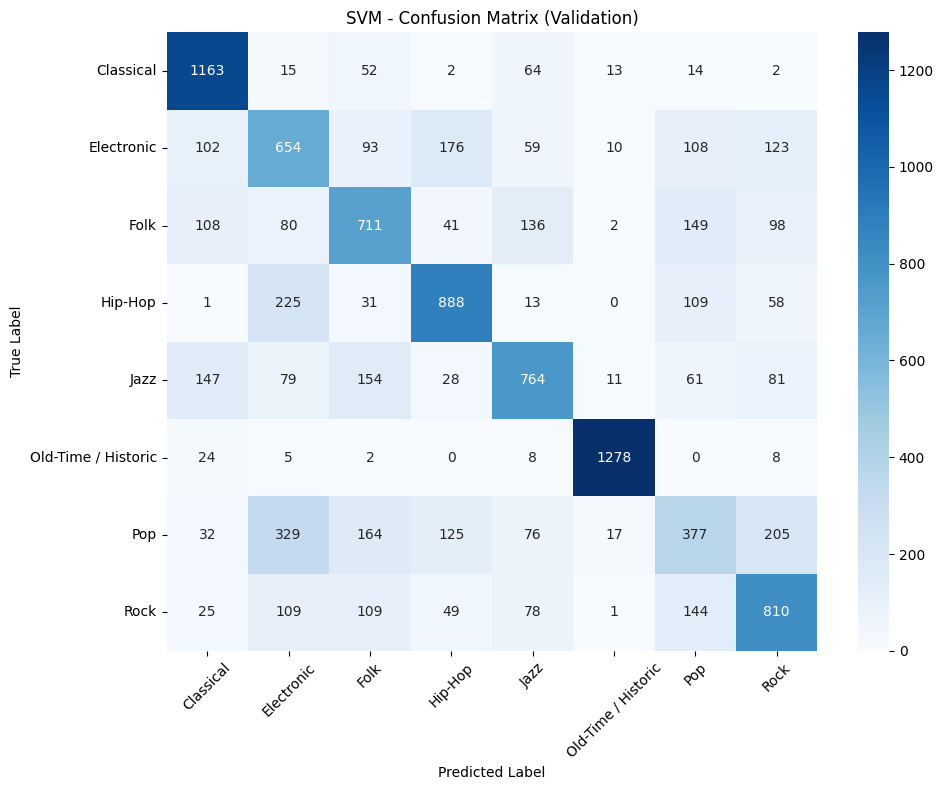

In [ ]:
# ---------------------------------------------------
# CONFUSION MATRIX VALIDATION SET
# ---------------------------------------------------
cm = confusion_matrix(y_val, y_val_pred)

# Get sorted unique class labels
classes = np.unique(np.concatenate((y_val, y_val_pred)))

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,                       # Show numbers inside cells
    fmt="d",                          # Integer format
    cmap="Blues",                     # Color map
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM - Confusion Matrix (Validation)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

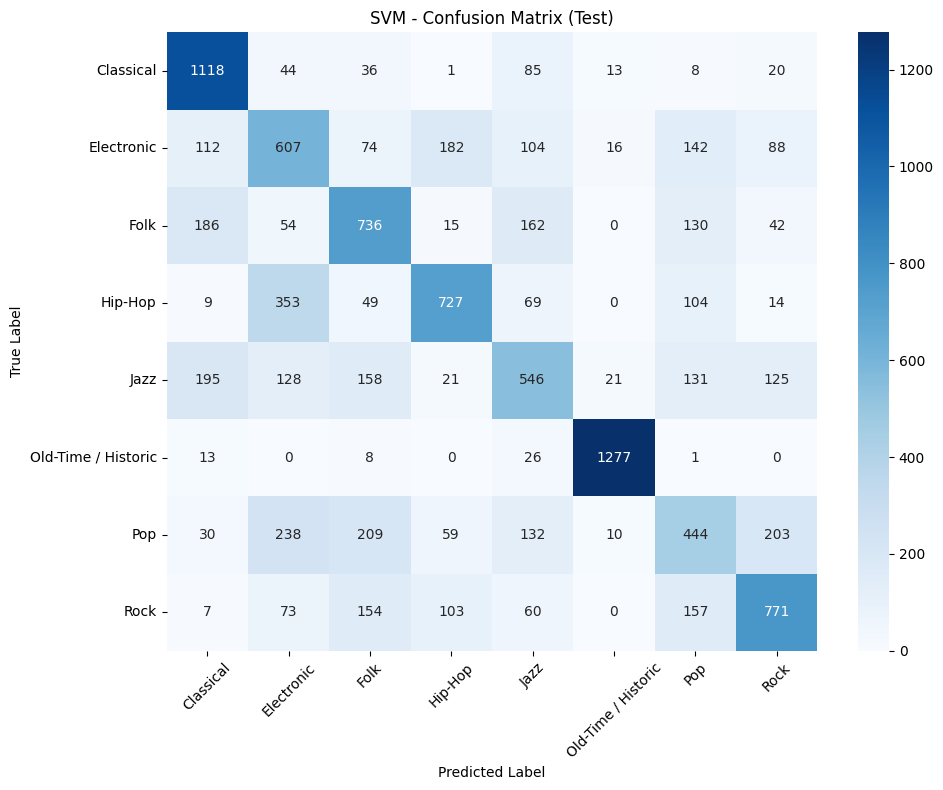

In [ ]:
# ---------------------------------------------------
# CONFUSION MATRIX VALIDATION SET
# ---------------------------------------------------
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,                       # Show numbers inside cells
    fmt="d",                          # Integer format
    cmap="Blues",                     # Color map
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM - Confusion Matrix (Test)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# IDENTIFY MISCLASSIFIED TEST SAMPLES
# ---------------------------------------------------------

# Generate predicted class probabilities for the test set
y_pred_probs = svm_clf.predict(X_test)
y_pred_labels = y_pred_probs
y_true_labels = y_test

# Create analysis DataFrame
# Create a copy of the original test DataFrame
# This ensures the original data remains unchanged
analysis_df = df_features_tracks_test.copy()
analysis_df['true_genre'] = y_true_labels
analysis_df['predicted_genre'] = y_pred_labels

# Identify misclassified samples
# Filter rows where prediction does not match the true label
misclassified = analysis_df[analysis_df['true_genre'] != analysis_df['predicted_genre']]

# Print misclassification DataFrame
print(misclassified[['track_id', 'true_genre', 'predicted_genre']])

      track_id true_genre predicted_genre
1       058783  Classical            Jazz
16      058783  Classical            Jazz
91      050906  Classical      Electronic
96      050906  Classical      Electronic
101     032044  Classical            Jazz
...        ...        ...             ...
10595   001287       Rock         Hip-Hop
10596   001287       Rock             Pop
10597   001287       Rock         Hip-Hop
10598   001287       Rock         Hip-Hop
10599   001287       Rock             Pop

[4374 rows x 3 columns]



=== SEGMENT-LEVEL TEST EVALUATION ===
Accuracy: 0.5873584905660377
Macro-F1: 0.5829972444872693

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.67      0.84      0.75      1325
         Electronic       0.41      0.46      0.43      1325
               Folk       0.52      0.56      0.54      1325
            Hip-Hop       0.66      0.55      0.60      1325
               Jazz       0.46      0.41      0.44      1325
Old-Time / Historic       0.96      0.96      0.96      1325
                Pop       0.40      0.34      0.36      1325
               Rock       0.61      0.58      0.60      1325

           accuracy                           0.59     10600
          macro avg       0.58      0.59      0.58     10600
       weighted avg       0.58      0.59      0.58     10600


=== TRACK-LEVEL TEST EVALUATION: MAJORITY VOTING ===
Accuracy: 0.6438679245283019
Macro-F1: 0.6399190854858694

Classification Report:
        

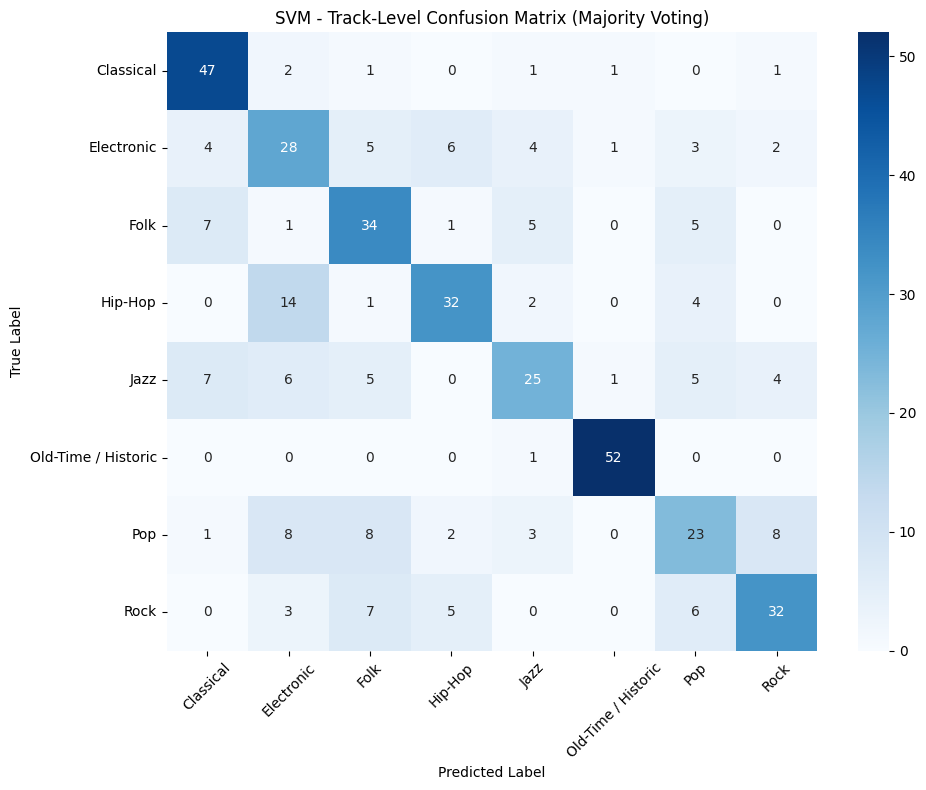


=== TRACK-LEVEL TEST EVALUATION: MEAN PROBABILITY ===
Accuracy: 0.6509433962264151
Macro-F1: 0.6470147566514453

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.73      0.91      0.81        53
         Electronic       0.49      0.53      0.51        53
               Folk       0.59      0.64      0.61        53
            Hip-Hop       0.72      0.64      0.68        53
               Jazz       0.57      0.47      0.52        53
Old-Time / Historic       0.96      0.98      0.97        53
                Pop       0.46      0.43      0.45        53
               Rock       0.67      0.60      0.63        53

           accuracy                           0.65       424
          macro avg       0.65      0.65      0.65       424
       weighted avg       0.65      0.65      0.65       424



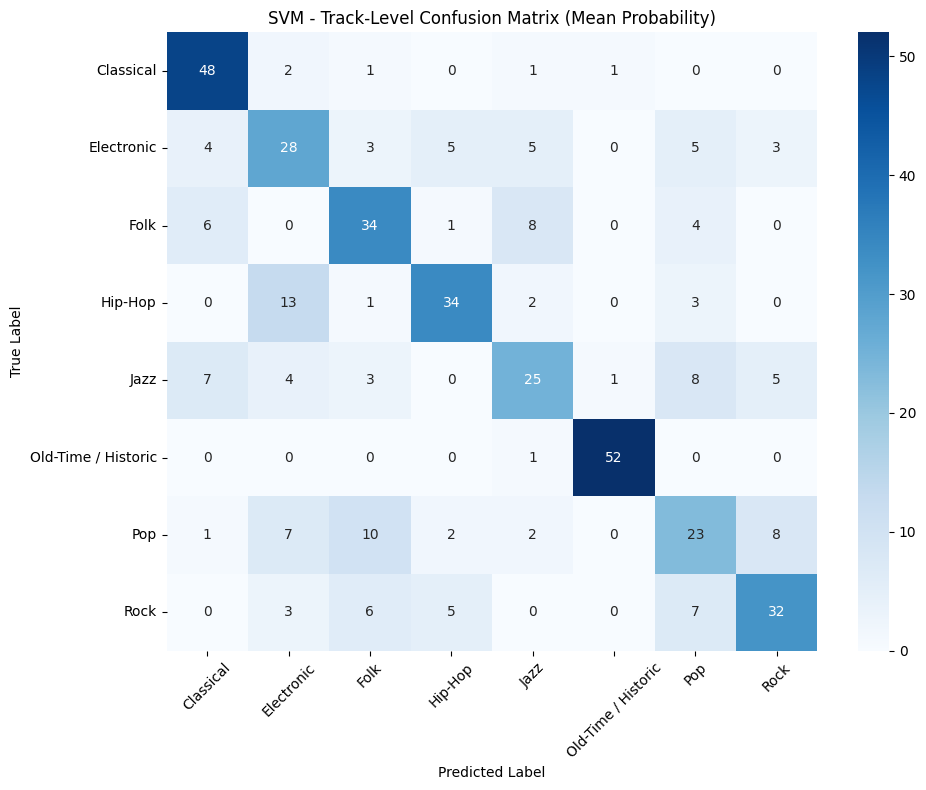


Saved segment- and track-level result CSV files to:
J:/Documents/FH/Git Repo Processing/MA_FMA_Dataprocessing/Models_final/Results


In [ ]:
# ---------------------------------------------------------
# TRACK-LEVEL EVALUATION (TEST SET)
# ---------------------------------------------------------
# The model was trained and evaluated on 3-second segments.
# For a track-level evaluation, all segment predictions belonging to the same
# track_id are aggregated into one final prediction per track.

# Build a metadata DataFrame that has the same row order as X_test / y_test
# This is required so every segment prediction can be assigned to its original track.
test_meta_df = df_features_tracks_test[df_features_tracks_test["genre"].notna()].reset_index(drop=True).copy()

# Safety check: X_test, y_test and metadata must have the same number of rows
assert len(test_meta_df) == len(y_test) == len(X_test), (
    f"Length mismatch: metadata={len(test_meta_df)}, y_test={len(y_test)}, X_test={len(X_test)}"
)

# Segment-level predictions and probabilities
test_pred_proba = svm_clf.predict_proba(X_test)
segment_pred_labels = svm_clf.predict(X_test)
class_names = list(svm_clf.classes_)

# Store segment-level prediction details in one DataFrame
segment_analysis_df = test_meta_df[["track_id", "genre"]].copy()
segment_analysis_df["true_genre"] = np.array(y_test).astype(str)
segment_analysis_df["predicted_genre"] = np.array(segment_pred_labels).astype(str)

# Add one probability column per class
for class_idx, class_name in enumerate(class_names):
    segment_analysis_df[f"prob_{class_name}"] = test_pred_proba[:, class_idx]

# ---------------------------------------------------------
# SEGMENT-LEVEL METRICS
# ---------------------------------------------------------
print("\n=== SEGMENT-LEVEL TEST EVALUATION ===")
print("Accuracy:", accuracy_score(segment_analysis_df["true_genre"], segment_analysis_df["predicted_genre"]))
print("Macro-F1:", f1_score(segment_analysis_df["true_genre"], segment_analysis_df["predicted_genre"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    segment_analysis_df["true_genre"],
    segment_analysis_df["predicted_genre"],
    labels=class_names,
    target_names=class_names
))

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION: MAJORITY VOTING
# ---------------------------------------------------------
track_majority_df = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"])["predicted_genre"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"predicted_genre": "predicted_genre_majority"})
)

print("\n=== TRACK-LEVEL TEST EVALUATION: MAJORITY VOTING ===")
print("Accuracy:", accuracy_score(track_majority_df["true_genre"], track_majority_df["predicted_genre_majority"]))
print("Macro-F1:", f1_score(track_majority_df["true_genre"], track_majority_df["predicted_genre_majority"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    track_majority_df["true_genre"],
    track_majority_df["predicted_genre_majority"],
    labels=class_names,
    target_names=class_names
))

cm_majority = confusion_matrix(
    track_majority_df["true_genre"],
    track_majority_df["predicted_genre_majority"],
    labels=class_names
)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_majority, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM - Track-Level Confusion Matrix (Majority Voting)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION: MEAN PROBABILITY
# ---------------------------------------------------------
prob_cols = [f"prob_{class_name}" for class_name in class_names]

track_probability_df = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"])[prob_cols]
    .mean()
    .reset_index()
)

# Select the class with the highest mean probability as final track prediction
mean_prob_values = track_probability_df[prob_cols].to_numpy()
track_probability_df["predicted_genre_mean_probability"] = [
    class_names[idx] for idx in np.argmax(mean_prob_values, axis=1)
]

print("\n=== TRACK-LEVEL TEST EVALUATION: MEAN PROBABILITY ===")
print("Accuracy:", accuracy_score(track_probability_df["true_genre"], track_probability_df["predicted_genre_mean_probability"]))
print("Macro-F1:", f1_score(track_probability_df["true_genre"], track_probability_df["predicted_genre_mean_probability"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    track_probability_df["true_genre"],
    track_probability_df["predicted_genre_mean_probability"],
    labels=class_names,
    target_names=class_names
))

cm_mean_probability = confusion_matrix(
    track_probability_df["true_genre"],
    track_probability_df["predicted_genre_mean_probability"],
    labels=class_names
)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mean_probability, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM - Track-Level Confusion Matrix (Mean Probability)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# SAVE TRACK-LEVEL RESULTS
# ---------------------------------------------------------
# Store segment-level and track-level results for later error analysis.
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Segment-level misclassifications.
segment_misclassified = segment_analysis_df[
    segment_analysis_df["true_genre"] != segment_analysis_df["predicted_genre"]
]

segment_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_segments.csv",
    index=False
)

# Track-level predictions: Majority Voting.
track_majority_export = track_majority_df.rename(
    columns={"predicted_genre_majority": "predicted_genre"}
)

track_majority_export[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_majority.csv",
    index=False
)

# Track-level predictions: Mean Probability.
track_probability_export = track_probability_df.rename(
    columns={"predicted_genre_mean_probability": "predicted_genre"}
)

track_probability_export[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_mean_probability.csv",
    index=False
)

# Track-level misclassifications: Majority Voting.
track_majority_misclassified = track_majority_export[
    track_majority_export["true_genre"] != track_majority_export["predicted_genre"]
]

track_majority_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_majority.csv",
    index=False
)

# Track-level misclassifications: Mean Probability.
track_probability_misclassified = track_probability_export[
    track_probability_export["true_genre"] != track_probability_export["predicted_genre"]
]

track_probability_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_mean_probability.csv",
    index=False
)

print("\nSaved segment- and track-level result CSV files to:")
print(MODEL_RESULTS_DIR)
